Fazer hoje:
1) dar merge nos datasets pra conseguir extrair o percentual de acertos nas notas
2) análise exploratória da relação tri X percentual de acerto (conferir se a ju já na2o fez isso
3) NMF
4) análise temporal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import drive
import json
import gdown
import plotly.graph_objects as go

In [ ]:
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_id = "1bGk3GbBptzPONHS3dxOWswk-LlXEwUGE"
url = f"https://drive.google.com/uc?id={file_id}"
df_ia = pd.read_parquet(url)

In [ ]:
#gdown.download(f"https://drive.google.com/uc?id=1oOqypOZxnpkbSLlO-X_Wu9RkFNrnW267", "/content/MICRODADOS_ENEM_2023.csv", quiet=False)
df_original = pd.read_parquet("/content/enems_subamostra.parquet")
#https://drive.google.com/file/d/1BywhuZ5hVhWL7bzAjJh9_FQfX7hc8ICI/view?usp=sharing
#https://drive.google.com/file/d/1oOqypOZxnpkbSLlO-X_Wu9RkFNrnW267/view?usp=sharing

In [ ]:
df_original.columns

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_SEXO', 'TP_FAIXA_ETARIA',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO',
       'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',
       'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'TP_PRESENCA_CN',
       'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'CO_PROVA_CN',
       'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH',
       'NU_NOTA_LC', 'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH',
       'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TP_STATUS_REDACAO',
       'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
       'NU_NOTA_COMP5', 'NU_NOTA_REDACAO', 'Q001', 'Q002', 'Q003', 'Q004',
       'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013',
       'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022',
       'Q023', 'Q024', 'Q025'],
      dty

In [ ]:
df_q= df_original[['CO_MUNICIPIO_ESC', 'SG_UF_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT',
            'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
            'NU_NOTA_COMP5', 'NU_NOTA_REDACAO']]

In [ ]:
df_q.head(15)

,CO_MUNICIPIO_ESC,SG_UF_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,1505502.0,PA,412.5,417.2,485.1,446.2,140.0,120.0,120.0,80.0,120.0,580.0
1,NaN,None,511.9,492.8,478.5,432.8,120.0,160.0,120.0,120.0,80.0,600.0
2,1505536.0,PA,465.0,570.9,574.2,614.0,140.0,160.0,160.0,120.0,140.0,720.0
3,NaN,None,404.6,487.1,443.4,388.6,120.0,120.0,120.0,80.0,80.0,520.0
4,NaN,None,555.6,485.6,507.7,472.0,120.0,120.0,120.0,120.0,60.0,540.0
5,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,None,464.0,369.1,499.8,590.2,120.0,100.0,120.0,120.0,40.0,500.0
7,NaN,None,461.2,418.7,356.6,519.3,100.0,120.0,120.0,100.0,120.0,560.0
8,NaN,None,408.5,553.3,544.1,390.6,140.0,160.0,160.0,140.0,160.0,760.0
9,1501402.0,PA,404.0,516.6,502.4,522.1,120.0,160.0,140.0,160.0,140.0,720.0


In [ ]:
df_q = df_q.dropna()

In [ ]:
df_q.head(5)

,CO_MUNICIPIO_ESC,SG_UF_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,1505502.0,PA,412.5,417.2,485.1,446.2,140.0,120.0,120.0,80.0,120.0,580.0
2,1505536.0,PA,465.0,570.9,574.2,614.0,140.0,160.0,160.0,120.0,140.0,720.0
9,1501402.0,PA,404.0,516.6,502.4,522.1,120.0,160.0,140.0,160.0,140.0,720.0
14,1508100.0,PA,401.6,480.3,526.3,512.9,80.0,120.0,100.0,80.0,0.0,380.0
15,1504208.0,PA,591.9,584.4,573.4,576.7,120.0,120.0,120.0,120.0,120.0,600.0


In [ ]:
df_q.columns

Index(['CO_MUNICIPIO_ESC', 'SG_UF_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH',
       'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2',
       'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'],
      dtype='object')

In [ ]:
# df_q = df_q[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT',
#             'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
#             'NU_NOTA_COMP5', 'NU_NOTA_REDACAO', 'CO_MUNICIPIO_PROVA', 'SG_UF_PROVA']]

### **Análise dos índices de acerto**

In [ ]:
df_ia.head(5)

,Questão,Indice de acerto
0,1,0.546560
1,2,0.286326
2,3,0.262026
3,4,0.463388
4,5,0.475454


In [ ]:
df_ia.describe()

,Questão,Indice de acerto
count,180.000000,180.000000
mean,90.500000,0.321530
std,52.105662,0.184607
min,1.000000,0.028984
25%,45.750000,0.190607
50%,90.500000,0.275535
75%,135.250000,0.451045
max,180.000000,0.883398


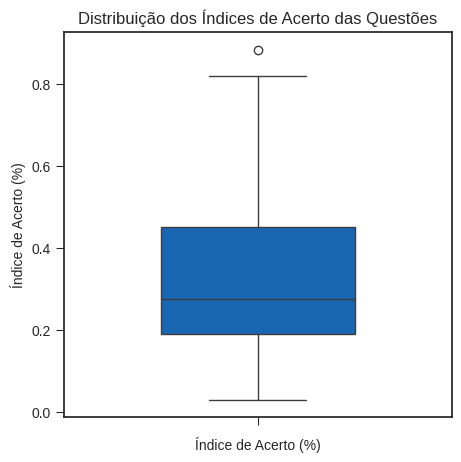

In [ ]:
plt.figure(figsize=(5, 5))
sns.boxplot(y=df_ia['Indice de acerto'], color = "#0066cc", fill = True, width = 0.5)
plt.xlabel("Índice de Acerto (%)")
plt.ylabel("Índice de Acerto (%)")
plt.title("Distribuição dos Índices de Acerto das Questões")

plt.show()

In [ ]:
print(f"Índice de Acerto Médio: {df_ia['Indice de acerto'].mean():.3f}%")
print(f"Índice de Acerto Mínimo: {df_ia['Indice de acerto'].min():.3f}%")
print(f"Questão com menor acerto: {df_ia.loc[df_ia['Indice de acerto'].idxmin(), 'Questão']}")
print(f"Índice de Acerto Máximo: {df_ia['Indice de acerto'].max():.3f}%")
print(f"Questão com maior acerto: {df_ia.loc[df_ia['Indice de acerto'].idxmax(), 'Questão']}")

Índice de Acerto Médio: 0.322%
Índice de Acerto Mínimo: 0.029%
Questão com menor acerto: 44
Índice de Acerto Máximo: 0.883%
Questão com maior acerto: 92


### **Análise das Notas Oficiais**

In [ ]:
df_q.describe()

,CO_MUNICIPIO_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
count,5.041300e+04,50413.000000,50413.000000,50413.000000,50413.000000,50413.000000,50413.000000,50413.000000,50413.000000,50413.000000,50413.000000
mean,3.188079e+06,491.557664,522.173541,518.981533,540.744239,122.225616,138.419455,118.381767,130.660742,112.093309,621.780890
std,9.922038e+05,79.774715,86.357881,73.826396,118.292436,34.519602,49.465055,40.606268,41.029773,61.064311,203.551411
min,1.100015e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.408102e+06,431.900000,461.600000,473.100000,445.300000,120.000000,120.000000,100.000000,120.000000,80.000000,520.000000
50%,3.201209e+06,485.300000,526.900000,525.700000,526.400000,120.000000,120.000000,120.000000,120.000000,120.000000,620.000000
75%,3.550308e+06,547.400000,583.500000,571.200000,626.800000,140.000000,180.000000,140.000000,160.000000,160.000000,760.000000
max,5.300108e+06,825.000000,823.400000,820.500000,985.000000,200.000000,200.000000,200.000000,200.000000,200.000000,980.000000


In [ ]:
#df_sample = df_q.sample(n=500000).reset_index(drop=True)
df_q.shape

(50413, 12)

In [ ]:
df_melted = df_q.melt(value_vars=['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT'],
                       var_name="Disciplina",
                       value_name="Nota")
label_dict = {
    'NU_NOTA_CN': 'Nota de Ciências Naturais',
    'NU_NOTA_CH': 'Nota de Ciências Humanas',
    'NU_NOTA_LC': 'Nota de Linguagens e Códigos',
    'NU_NOTA_MT': 'Nota de Matemática'
}

df_melted["Disciplina"] = df_melted["Disciplina"].map(label_dict)

<Figure size 1600x1200 with 0 Axes>

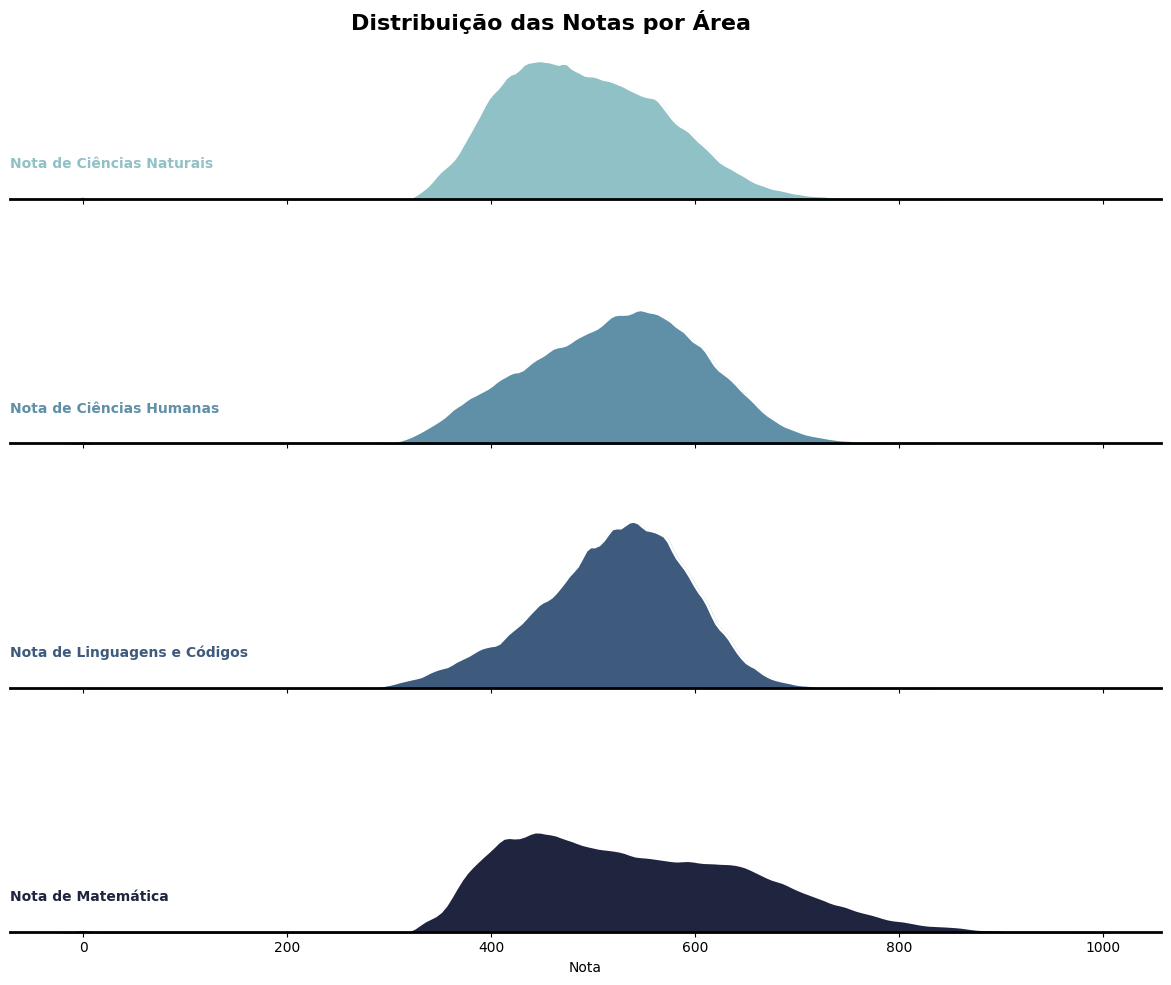

In [ ]:
pal = sns.cubehelix_palette(n_colors=4, rot=-.25, light=.7)
plt.figure(figsize=(16, 12))
g = sns.FacetGrid(df_melted, row="Disciplina", hue="Disciplina", aspect=5, height=2.5, palette=pal)

g.map(sns.kdeplot, "Nota", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "Nota", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.refline(y=0, linewidth=2, linestyle="-", color="black", clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(x.min(), 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, "Nota")
g.figure.subplots_adjust(hspace=0.4)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.fig.suptitle('Distribuição das Notas por Área', fontsize=16, fontweight='bold')
plt.show()

<ipython-input-16-59a9c8809f65>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-16-59a9c8809f65>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


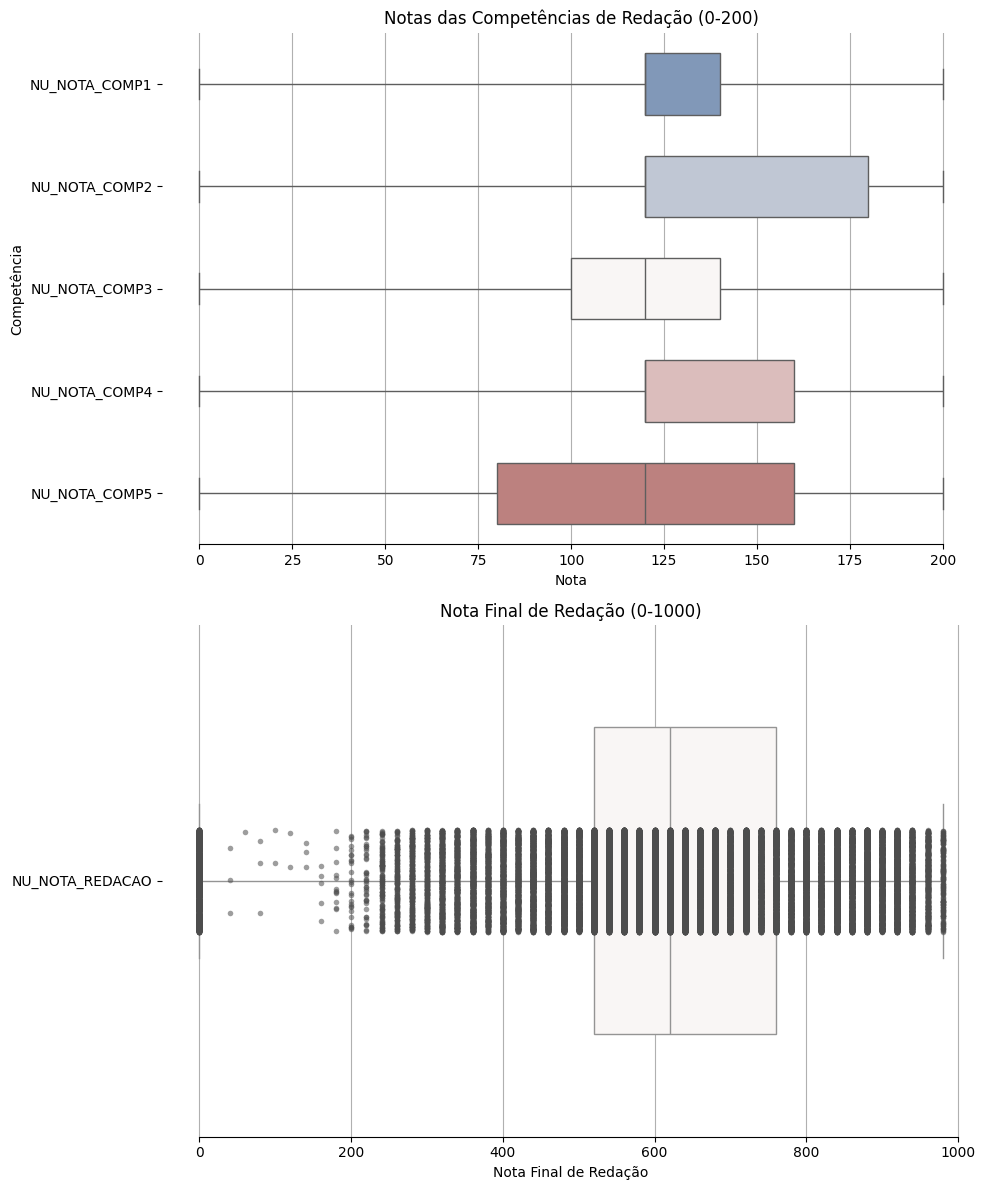

In [ ]:
competencias = ['NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5']
nota_final = ['NU_NOTA_REDACAO']
df_competencias_melted = df_q.melt(id_vars=[], value_vars=competencias, var_name='Competencia', value_name='Nota')
df_nota_final_melted = df_q.melt(id_vars=[], value_vars=nota_final, var_name='Competencia', value_name='Nota')


f, axes = plt.subplots(2, 1, figsize=(10, 12))
sns.boxplot(
    data=df_competencias_melted, x="Nota", y="Competencia", whis=[0, 100], width=.6, palette="vlag", ax=axes[0]
)
#sns.stripplot(data=df_competencias_melted, x="Nota", y="Competencia", size=4, color=".3", jitter=True, ax=axes[0])

axes[0].xaxis.grid(True)
axes[0].set(xlabel="Nota", ylabel="Competência")
axes[0].set_title("Notas das Competências de Redação (0-200)")
sns.despine(trim=True, left=True, ax=axes[0])


sns.boxplot(
    data=df_nota_final_melted, x="Nota", y="Competencia", whis=[0, 100], width=.6, palette="vlag", ax=axes[1]
)
sns.stripplot(data=df_nota_final_melted, x="Nota", y="Competencia", size=4, color=".3", jitter=True, ax=axes[1], alpha=0.55)

axes[1].xaxis.grid(True)
axes[1].set(xlabel="Nota Final de Redação", ylabel="")
axes[1].set_title("Nota Final de Redação (0-1000)")
sns.despine(trim=True, left=True, ax=axes[1])


plt.tight_layout()
plt.show()

### **Análise Detalhada (outras variáveis)**

In [ ]:
regioes = {
    'AC': 'Norte', 'AL': 'Nordeste', 'AP': 'Norte', 'AM': 'Norte', 'BA': 'Nordeste', 'CE': 'Nordeste',
    'DF': 'Centro-Oeste', 'ES': 'Sudeste', 'GO': 'Centro-Oeste', 'MA': 'Nordeste', 'MT': 'Centro-Oeste',
    'MS': 'Centro-Oeste', 'MG': 'Sudeste', 'PA': 'Norte', 'PB': 'Nordeste', 'PR': 'Sul', 'PE': 'Nordeste',
    'PI': 'Nordeste', 'RJ': 'Sudeste', 'RN': 'Nordeste', 'RS': 'Sul', 'RO': 'Norte', 'RR': 'Norte',
    'SC': 'Sul', 'SP': 'Sudeste', 'SE': 'Nordeste', 'TO': 'Norte'
}

df_q['regiao'] = df_q['SG_UF_ESC'].map(regioes)

In [ ]:
#swarmplot com prova na horizontal e notas na vertical e separado por cor de acordo com a regiao
plt.style.use("seaborn-v0_8-ticks")
cores_regiao = {
    'Nordeste': '#e61c1c',
    'Norte': '#f17106',
    'Centro-Oeste': '#cbf607',
    'Sudeste': '#1ccd37',
    'Sul': '#0fb7d1'
}
colunas_notas = {
    'NU_NOTA_CN': 'Ciências da Natureza',
    'NU_NOTA_MT': 'Matemática',
    'NU_NOTA_LC': 'Linguagens e Códigos',
    'NU_NOTA_CH': 'Ciências Humanas'
}


df_melted = df_q.melt(id_vars=['regiao'],
                            value_vars=colunas_notas.keys(),
                            var_name='Prova',
                            value_name='Nota')

df_melted['Prova'] = df_melted['Prova'].map(colunas_notas)

plt.figure(figsize=(10, 6))
sns.swarmplot(
    data=df_melted,
    x='Prova',
    y='Nota',
    hue='regiao',
    palette=cores_regiao,
    edgecolor='black',
    alpha=0.85
)
plt.legend(title="Região", loc='lower left', frameon=True)
plt.xlabel("")
plt.ylabel("Nota Oficial")
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7ea5bfecc400> (for post_execute):


KeyboardInterrupt: 

In [ ]:
#boxplots comparativos p cada area do conhecimento com plotly (grouped boxplots ou fully styled boxplots)
fig = px.box(
    df_q,
    x="regiao",
    y="NU_NOTA_REDACAO",
    color="regiao",
    color_discrete_map=cores_regiao,
    title="Distribuição das Notas de Redação por Região"
)

fig.update_layout(
    legend=dict(
        title="Região",
        x=1, y=0,
        xanchor="right", yanchor="bottom"
    ),
    xaxis_title="Região",
    yaxis_title="Nota de Redação"
)
fig.show()

In [ ]:
fig = go.Figure()
competencias = ['NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5']
espacamento_inter = 1.2
espacamento_ext = 0.18

for i, competencia in enumerate(competencias):
    for j, regiao in enumerate(cores_regiao.keys()):
        x_pos = i * espacamento_inter + j * espacamento_ext

        fig.add_trace(go.Box(
            y=df_q[df_q['regiao'] == regiao][competencia],
            name=f"{competencia} - {regiao}",
            boxpoints="all",
            jitter=0.5,
            pointpos=-1.8,
            marker_size=3,
            line_width=1,
            fillcolor=cores_regiao[regiao],
            marker_color=cores_regiao[regiao],
            line_color="black"
        ))

fig.update_layout(
    title="Distribuição das Notas das Competências de Redação por Região",
    xaxis=dict(
        tickvals=[i * espacamento_inter + 0.3 for i in range(len(competencias))],
        ticktext=competencias,
        title="Competências",
    ),
    yaxis=dict(title="Nota"),
    boxmode="group",
    showlegend=False
)

fig.show()

In [ ]:
with open('br_states.json') as f:
    geojson = json.load(f)

fig = px.choropleth(df_q,
                    geojson=geojson,
                    locations='SG_UF_PROVA',
                    color='NU_NOTA_CH',
                    hover_name='SG_UF_PROVA',
                    color_continuous_scale="RdBu",
                    title="Notas de Ciências Humanas por Estado"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
with open('br_states.json') as f:
    geojson = json.load(f)

fig = px.choropleth(df_q,
                    geojson=geojson,
                    locations='SG_UF_ESC',
                    color='NU_NOTA_LC',
                    hover_name='SG_UF_ESC',
                    color_continuous_scale="RdBu",
                    title="Notas de Linguagens por Estado"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
fig = px.choropleth(df_q,
                    geojson=geojson,
                    locations='SG_UF_ESC',
                    color='NU_NOTA_MT',
                    hover_name='SG_UF_ESC',
                    color_continuous_scale="RdBu",
                    title="Notas de Matemática por Estado"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
fig = px.choropleth(df_q,
                    geojson=geojson,
                    locations='SG_UF_ESC',
                    color='NU_NOTA_CN',
                    hover_name='SG_UF_ESC',
                    color_continuous_scale="RdBu",
                    title="Notas de Ciências da Natureza por Estado"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

### **Análise TRI: Nota Oficial X Percentual de Acertos**

In [ ]:
# colunas_desejadas = ['TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC',
#        'TX_RESPOSTAS_MT', 'TX_RESPOSTAS_CN' 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH',
#        'TX_GABARITO_LC', 'TX_GABARITO_MT']
df_cresps = pd.read_parquet("/content/gabaritos.parquet")
df_cresps.columns

Index(['COR', 'ANO', 'COMPETENCIA', 'CO_PROVA', 'TX_GABARITO'], dtype='object')

In [ ]:
df_q.merge(df_cresps, on='', how='left')

,CO_MUNICIPIO_ESC,SG_UF_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,1505502.0,PA,412.5,417.2,485.1,446.2,140.0,120.0,120.0,80.0,120.0,580.0
2,1505536.0,PA,465.0,570.9,574.2,614.0,140.0,160.0,160.0,120.0,140.0,720.0
9,1501402.0,PA,404.0,516.6,502.4,522.1,120.0,160.0,140.0,160.0,140.0,720.0
14,1508100.0,PA,401.6,480.3,526.3,512.9,80.0,120.0,100.0,80.0,0.0,380.0
15,1504208.0,PA,591.9,584.4,573.4,576.7,120.0,120.0,120.0,120.0,120.0,600.0
...,...,...,...,...,...,...,...,...,...,...,...,...
299971,2112803.0,MA,443.2,448.6,404.6,337.8,0.0,0.0,0.0,0.0,0.0,0.0
299972,3139003.0,MG,602.9,574.8,487.7,578.8,120.0,160.0,120.0,120.0,80.0,600.0
299978,3301009.0,RJ,530.7,531.5,504.7,499.9,120.0,160.0,120.0,140.0,160.0,700.0
299993,2100055.0,MA,493.4,429.5,481.8,594.9,120.0,120.0,120.0,120.0,80.0,560.0


In [ ]:
def calcular_acertos(respostas, gabarito):
    # Compara cada caractere das strings de respostas e gabarito
    return [1 if r == g else 0 for r, g in zip(respostas, gabarito)]

df['acertos CN'] = df.apply(lambda row: calcular_acertos(row['TX_GABARITO_CN'], row['TX_GABARITO_CN']), axis=1)
df['acertos MT'] = df.apply(lambda row: calcular_acertos(row['TX_RESPOSTAS_MT'], row['TX_GABARITO_MT']), axis=1)
df['acertos CH'] = df.apply(lambda row: calcular_acertos(row['TX_RESPOSTAS_CH'], row['TX_GABARITO_CH']), axis=1)
df['acertos LC'] = df.apply(lambda row: calcular_acertos(row['TX_RESPOSTAS_LC'], row['TX_GABARITO_LC']), axis=1)

In [ ]:
def calcular_nota_por_acertos(acertos):
    return sum(acertos) / 45 * 1000

df['nota por acertos CN'] = df['acertos CN'].apply(calcular_nota_por_acertos)
df['nota por acertos MT'] = df['acertos MT'].apply(calcular_nota_por_acertos)
df['nota por acertos CH'] = df['acertos CH'].apply(calcular_nota_por_acertos)
df['nota por acertos LC'] = df['acertos LC'].apply(calcular_nota_por_acertos)

In [ ]:
#matriz de correlacao notas oficias X percentual de acerto

In [ ]:
#grafico da distribuicao das diferencas